Imports and Settings

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
from enum import Enum

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch.nn import MSELoss, CrossEntropyLoss
from torch.optim import SGD
from torch.utils.data import DataLoader
import torch.nn.functional as F

from data import (
    GaussianDataset,
    LinearGaussianDataset,
    RectangularDataset,
    SpiralDataset,
    YinYangDataset,
)
from models.perceptron import MLP, init_weights
from visualization.boundary import plot_decision_boundary_movie
from safetensors.torch import load_model, save_model

In [ ]:
# Make sure you have the correct matplotlib backend
%matplotlib inline

In [ ]:
# Custom formatter function
def my_formatter(x):
    if abs(x) < 1e-0 or abs(x) >= 1e0:  # Threshold for scientific notation
        return f"{x:.2e}"  # Format as scientific with 2 decimal places
    else:
        return f"{x:.2f}"  # Format as decimal with 2 decimal places


# Set print options with custom formatter
torch.set_printoptions(linewidth=100, sci_mode=True)
np.set_printoptions(linewidth=100, formatter={"float_kind": my_formatter})

Control Panel

In [ ]:
class DatasetProblem(Enum):
    RECTANGULAR = "rectangular"
    SPIRAL = "spiral"
    LINEAR = "linear"
    GAUSSSIAN = "gaussian"
    YINYANG = "yinyang"


class ModelClass(Enum):
    MLP = "mlp"

In [ ]:
# DATASET
PROBLEM = DatasetProblem.YINYANG
NEGATIVE_LABEL = False
NOISE = 0.2  # only valid for SpiralDataset
NUM_SAMPLES = 2_000
NUM_GAUSS_FEATURES = 0

# VISUALIZATION
FIGSIZE = (20, 5)

Dataset

In [ ]:
# Build dataset
if PROBLEM == DatasetProblem.RECTANGULAR:
    dataset = RectangularDataset(
        num_samples=NUM_SAMPLES,
        num_extra_features=NUM_GAUSS_FEATURES,
        negative_label=NEGATIVE_LABEL,
    )
elif PROBLEM == DatasetProblem.SPIRAL:
    dataset = SpiralDataset(
        num_samples=NUM_SAMPLES, num_extra_features=NUM_GAUSS_FEATURES, noise=NOISE
    )
elif PROBLEM == DatasetProblem.LINEAR:
    dataset = LinearGaussianDataset(
        num_samples=NUM_SAMPLES, num_extra_features=NUM_GAUSS_FEATURES
    )
elif PROBLEM == DatasetProblem.GAUSSSIAN:
    dataset = GaussianDataset(
        num_samples=NUM_SAMPLES, num_extra_features=NUM_GAUSS_FEATURES
    )
elif PROBLEM == DatasetProblem.YINYANG:
    dataset = YinYangDataset(
        size=NUM_SAMPLES,
        negative_label=NEGATIVE_LABEL,
    )
else:
    raise NotImplementedError()

In [ ]:
# Extract data to numpy for visualization
features = dataset.features.numpy()
labels = dataset.labels.numpy()

Visualize Dataset

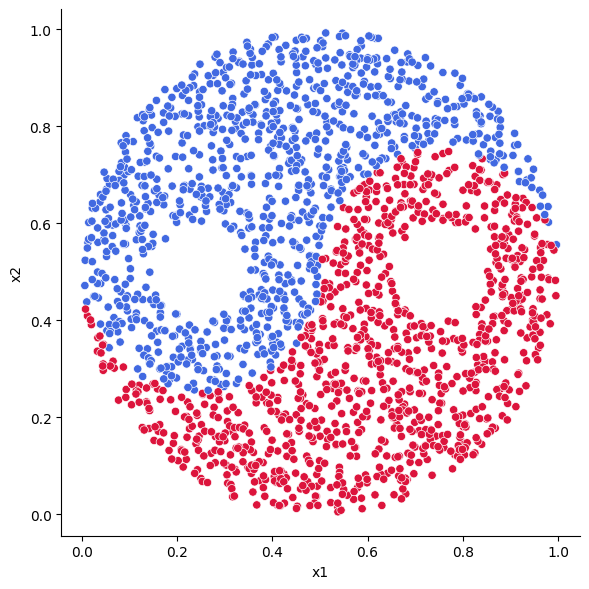

In [ ]:
# Grab only first two columns
df = pd.DataFrame(features[:, :2], columns=["x1", "x2"])

if NEGATIVE_LABEL:
    df["label"] = pd.Series(labels.squeeze(1)).apply(
        lambda x: "crimson" if x == -1 else "royalblue"
    )
else:
    df["label"] = pd.Series(labels.squeeze(1)).apply(
        lambda x: "crimson" if x == 0 else "royalblue"
    )

# Create the plot
plt.figure(figsize=(6, 6))  # Adjust size as needed

sns.scatterplot(
    x="x1", y="x2", hue="label", data=df, palette=["crimson", "royalblue"], legend=False
)
# Remove spines (the box around the plot)
sns.despine(left=False, bottom=False)

# Adjust plot margins (reduce padding)
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)

# Show the plot
plt.tight_layout()
plt.show()

Model Setup

In [ ]:
# MODEL
MODEL_CLASS = ModelClass.MLP
HIDDEN_NEURONS = [5, 5, 3]  # only valid for HiddenLayerModel
NONLINEARITY = "tanh" if NEGATIVE_LABEL else "relu"
# MODEL TRAINING
BATCH_SIZE = 2_000
NUM_EPOCHS = 30_000
LEARNING_RATE = 3e-1

In [ ]:
SAVE_FREQ = 500
PRINT_FREQ = 500

In [ ]:
if MODEL_CLASS == ModelClass.MLP:
    model = MLP(
        config=HIDDEN_NEURONS,
        in_features=features.shape[-1],
        nonlinearity=NONLINEARITY,
    )
else:
    raise NotImplementedError()

model.apply(init_weights)

MLP(
  (features): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=False)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=5, bias=True)
    (3): ReLU()
    (4): Linear(in_features=5, out_features=3, bias=True)
    (5): ReLU()
    (6): Linear(in_features=3, out_features=2, bias=False)
  )
)

Train Model

In [ ]:
dataloader = DataLoader(dataset=dataset, shuffle=True, batch_size=BATCH_SIZE)

In [ ]:
loss_vector = []

In [ ]:
criterion = CrossEntropyLoss()  # Use CrossEntropyLoss for multi-class classification
optimizer = SGD(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

In [ ]:
device = "cuda:0"
model.to(device=device)
model.train()
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0  # Track loss within the epoch

    for batch_idx, (input, label) in enumerate(dataloader):
        input, label = input.to(device), label.to(device)
        label = label.squeeze()

        optimizer.zero_grad()
        output = model(input)

        loss = criterion(output, label.long())
        loss.backward()
        optimizer.step()

        running_loss += loss.item()  # Accumulate loss

    epoch_loss = running_loss / len(dataloader)  # Average loss over all batches
    loss_vector.append(epoch_loss)  # Store loss for later analysis

    if (epoch + 1) % PRINT_FREQ == 0:
        print(f"Epoch {epoch + 1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}")

Epoch 500/30000, Loss: 0.2340
Epoch 1000/30000, Loss: 0.2254
Epoch 1500/30000, Loss: 0.2200
Epoch 2000/30000, Loss: 0.2109
Epoch 2500/30000, Loss: 0.2067
Epoch 3000/30000, Loss: 0.2117
Epoch 3500/30000, Loss: 0.2016
Epoch 4000/30000, Loss: 0.1997
Epoch 4500/30000, Loss: 0.1991
Epoch 5000/30000, Loss: 0.1931
Epoch 5500/30000, Loss: 0.1744
Epoch 6000/30000, Loss: 0.1304
Epoch 6500/30000, Loss: 0.1255
Epoch 7000/30000, Loss: 0.0969
Epoch 7500/30000, Loss: 0.1085
Epoch 8000/30000, Loss: 0.1859
Epoch 8500/30000, Loss: 0.0835
Epoch 9000/30000, Loss: 0.0612
Epoch 9500/30000, Loss: 0.0791
Epoch 10000/30000, Loss: 0.0758
Epoch 10500/30000, Loss: 0.0791
Epoch 11000/30000, Loss: 0.0463
Epoch 11500/30000, Loss: 0.0526
Epoch 12000/30000, Loss: 0.0713
Epoch 12500/30000, Loss: 0.0727
Epoch 13000/30000, Loss: 0.1801
Epoch 13500/30000, Loss: 0.0607
Epoch 14000/30000, Loss: 0.0736
Epoch 14500/30000, Loss: 0.0715
Epoch 15000/30000, Loss: 0.0515
Epoch 15500/30000, Loss: 0.0714
Epoch 16000/30000, Loss: 0.0

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object>>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py", line 770, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


Epoch 16500/30000, Loss: 0.0416
Epoch 17000/30000, Loss: 0.1750


KeyboardInterrupt: 

Decision Boundary

<matplotlib.animation.FuncAnimation>

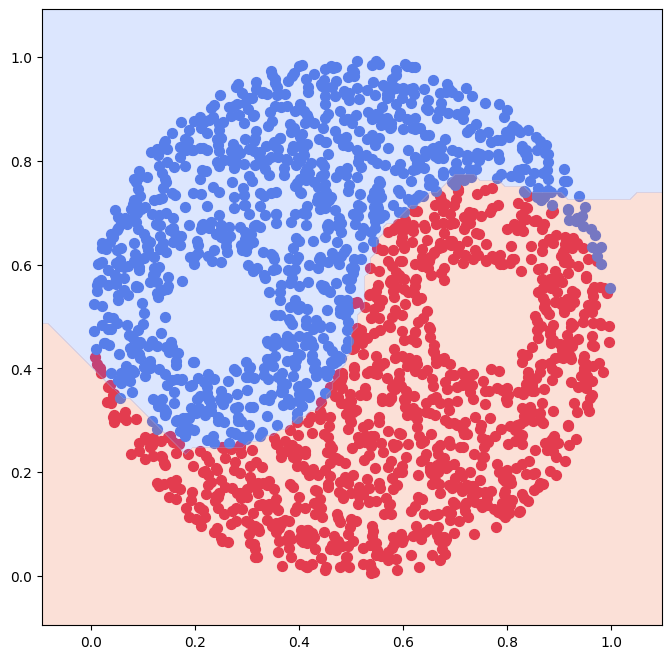

In [ ]:
plot_decision_boundary_movie(
    model,
    [model.state_dict()],
    features,
    labels.squeeze(),
    figsize=(8, 8),
    labels=[0, 1],
)